In [2]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

## README

This is a little intro notebook I made to test some code. It has some visualizers and other notes about the datasets that could be interesting to see

## ROSE Data Loader

In [3]:
# create class for ROSE dataset for torch later
class ROSE_Dataset(Dataset):
    def __init__(self, base_path, subsets=['SVC', 'DVC', 'SVC_DVC'], split='train', transform=None):
        # probs only gonna use SVC_DVC, that's superficial and deep vasculature combined
        # transforms if we're doing augmentations later
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []

        for subset in subsets:
            img_dir = os.path.join(base_path, subset, split, 'img')
            mask_dir = os.path.join(base_path, subset, split, 'gt')

            for fname in sorted(os.listdir(img_dir)):
                if fname.endswith('.png'):
                    self.image_paths.append(os.path.join(img_dir, fname))
                    self.mask_paths.append(os.path.join(mask_dir, fname.replace('.png', '.tif')))

    def __len__(self):
        return len(self.image_paths)
    
    
    def __getitem__(self, idx):
        image = np.array(cv2.cvtColor(cv2.imread((self.image_paths[idx])), cv2.COLOR_BGR2GRAY))
        mask = np.array(cv2.cvtColor(cv2.imread((self.mask_paths[idx])), cv2.COLOR_BGR2GRAY) > 0).astype(np.uint8)
        
        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

In [32]:
train_set_ROSE1 = ROSE_Dataset('ROSE_DATA/ROSE/ROSE-1/', subsets=['SVC_DVC'], split='train')
test_set_ROSE1 = ROSE_Dataset('ROSE_DATA/ROSE/ROSE-1/', subsets=['SVC_DVC'], split='test')

Train size: 30
Test size: 9
Image shape: (304, 304)
Mask shape: (304, 304)
Image range: 0 - 255
Mask unique values: [0 1]


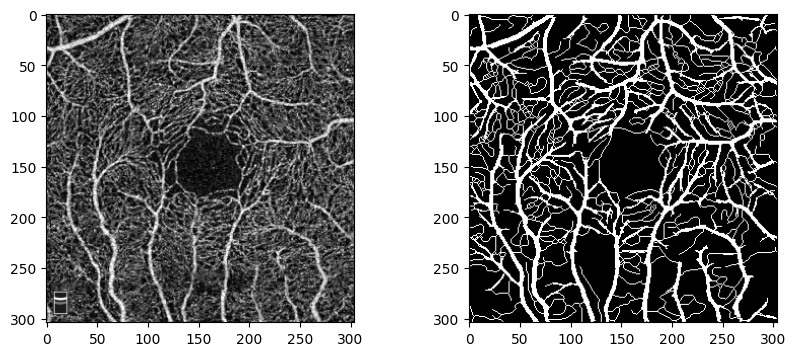

In [47]:
# confirm data dims
print(f"Train size: {len(train_set_ROSE1)}")  # expect 30
print(f"Test size: {len(test_set_ROSE1)}")    # expect 9

image, mask = train_set_ROSE1[0]
print(f"Image shape: {image.shape}")          # expect (304, 304)
print(f"Mask shape: {mask.shape}")            # expect (304, 304)
print(f"Image range: {image.min()} - {image.max()}")   # expect 0-255
print(f"Mask unique values: {np.unique(mask)}")  

# lets see an image and label
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(image,cmap='gray')
axs[1].imshow(mask,cmap='gray')

## OCTA500 Data loader

Only using the 3mm subset here cuz its dims match that of ROSE (304x304px)

In [ ]:
# create class for ROSE dataset for torch later
class OCTA3M_Dataset(Dataset):
    def __init__(self, base_path, split='train', transform=None):
        # transforms if we're doing augmentations later
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []


        img_dir = os.path.join(base_path, 'Img/Projection_Maps/OCTA(ILM_OPL)')
        mask_dir = os.path.join(base_path, 'Labels/GT_Capillary')

        for fname in sorted(os.listdir(img_dir)):
            if fname.endswith('.bmp'):
                self.image_paths.append(os.path.join(img_dir, fname))
                self.mask_paths.append(os.path.join(mask_dir, fname))

    def __len__(self):
        return len(self.image_paths)
    
    
    def __getitem__(self, idx):
        image = np.array(cv2.cvtColor(cv2.imread((self.image_paths[idx])), cv2.COLOR_BGR2GRAY))
        mask = np.array(cv2.cvtColor(cv2.imread((self.mask_paths[idx])), cv2.COLOR_BGR2GRAY) > 0).astype(np.uint8)
        
        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask